# M5 Practice: Data Visualization with  Data

This practice notebook provides additional preparation for Assignment 5. 

#### 1. Setup
* 1.1 Import the Path, Pandas, Seaborn, and Calendar packages into your notebook
* 1_2 Set path objects for your project folder, the raw data folder, and the `Processed_Key` folder

In [1]:
# 1_1 Packages
from pathlib import Path
import pandas as pd
import seaborn as sns
import calendar

In [2]:
# 1.2 Paths 
project_fldr = Path.cwd().parent.parent
raw_fldr = project_fldr / 'data' / 'raw'
processed_fldr = project_fldr / 'data' / 'Processed_Key'

In [3]:
# 1.3 Dictionary to map month to season
month_to_season = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
}

#### 2. Ingest Data & Wrangle
* Import the processed USGS Flow dataset (`SGS_Site02085000_Flow_Processed.csv`) - located in the `Processed_Key` folder. 
    - Set the datetime column to be a datetime object
    - Create `month`, `year`, and `season` columns. (Use the `month_to_season` dictionary for the `season` column.)
* Create a `month_abb` column of abbreviated month names, set as a categorical field with levels for each month. 
* Add a column indicating whether the record occurred before, during, or after Falls Lake dam construction. (Construction started in 1979 and completed in 1981 - [Source](https://www.saw.usace.army.mil/portals/59/docs/recreation/fallslake/images/falls%20lake%20master%20plan%20june%2021%202013%20final.pdf))

In [4]:
#Import USGS flow data, deriving month, year, and season columns from datetime
USGS_flow = (
    pd.read_csv(
        processed_fldr/'USGS_Site02085000_Flow_Processed.csv',
        usecols = [
            'datetime', 
            'discharge_max','discharge_min','discharge_mean',
            'gage_height_max', 'gage_height_min', 'gage_height_mean',
            ],
        parse_dates=['datetime']
    )
    .assign(
        month = lambda df: df['datetime'].dt.month,
        year = lambda df: df['datetime'].dt.year,
        season = lambda df: df['month'].map(month_to_season)
    )
)


USGS_flow['month_abb'] = pd.Categorical(
    values=USGS_flow['datetime'].dt.month_name().str[:3],
    categories=calendar.month_abbr[1:],
)

USGS_flow.sample(10,random_state=42)

,datetime,discharge_max,discharge_min,discharge_mean,gage_height_max,gage_height_min,gage_height_mean,month,year,season,month_abb
29303,2022-03-19,NaN,NaN,154.00,NaN,NaN,3.05,3,2022,Spring,Mar
19922,1996-07-12,NaN,NaN,8.70,NaN,NaN,1.52,7,1996,Summer,Jul
17409,1989-08-25,NaN,NaN,125.00,NaN,NaN,NaN,8,1989,Summer,Aug
2898,1935-12-08,NaN,NaN,12.00,NaN,NaN,NaN,12,1935,Winter,Dec
22259,2002-12-05,NaN,NaN,575.00,NaN,NaN,5.34,12,2002,Winter,Dec
3000,1936-03-19,NaN,NaN,340.00,NaN,NaN,NaN,3,1936,Spring,Mar
28052,2018-10-15,35.60,28.60,32.20,2.17,2.08,2.13,10,2018,Fall,Oct
25026,2010-07-03,3.13,2.97,3.02,0.98,0.97,0.97,7,2010,Summer,Jul
15621,1970-10-08,NaN,NaN,0.95,NaN,NaN,NaN,10,1970,Fall,Oct
210,1928-07-29,NaN,NaN,9.40,NaN,NaN,NaN,7,1928,Summer,Jul


In [5]:
#Create a month category, with levels for each month

USGS_flow.info()

<class 'pandas.DataFrame'>
RangeIndex: 30848 entries, 0 to 30847
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   datetime          30848 non-null  datetime64[us]
 1   discharge_max     5348 non-null   float64       
 2   discharge_min     5348 non-null   float64       
 3   discharge_mean    30848 non-null  float64       
 4   gage_height_max   5461 non-null   float64       
 5   gage_height_min   5461 non-null   float64       
 6   gage_height_mean  11161 non-null  float64       
 7   month             30848 non-null  int32         
 8   year              30848 non-null  int32         
 9   season            30848 non-null  str           
 10  month_abb         30848 non-null  category      
dtypes: category(1), datetime64[us](1), float64(6), int32(2), str(1)
memory usage: 2.1 MB


In [26]:
#Create a column indicating whether the record was collected before, during, or after dam construction
def construction_check (year): 
    if year < 1979: return 'before'
    elif year <= 1981: return 'during'
    else: return 'after'

USGS_flow ['construction_status'] = USGS_flow['year'].map(construction_check)    

In [7]:
#Examine the dataframe
USGS_flow.sample(10,random_state=2)


,datetime,discharge_max,discharge_min,discharge_mean,gage_height_max,gage_height_min,gage_height_mean,month,year,season,month_abb,construction_status
12933,1963-05-30,NaN,NaN,24.0,NaN,NaN,NaN,5,1963,Spring,May,before
26033,2013-04-05,272.0,106.00,187.0,3.61,2.80,3.24,4,2013,Spring,Apr,after
5593,1943-04-25,NaN,NaN,58.0,NaN,NaN,NaN,4,1943,Spring,Apr,before
17173,1989-01-01,NaN,NaN,126.0,NaN,NaN,NaN,1,1989,Winter,Jan,after
28075,2018-11-07,211.0,142.00,172.0,3.24,2.94,3.08,11,2018,Fall,Nov,after
12805,1963-01-22,NaN,NaN,149.0,NaN,NaN,NaN,1,1963,Winter,Jan,before
24144,2008-02-02,28.7,9.39,19.5,1.76,1.33,1.58,2,2008,Winter,Feb,after
10897,1957-11-01,NaN,NaN,16.0,NaN,NaN,NaN,11,1957,Fall,Nov,before
15722,1971-01-17,NaN,NaN,29.0,NaN,NaN,NaN,1,1971,Winter,Jan,before
25200,2010-12-24,11.6,8.85,10.1,1.28,1.22,1.25,12,2010,Winter,Dec,after


#### 3. Craft your Seaborn Theme
* Set your theme to be based on Seaborn's `whitegrid` template.
* As we are working in notebook format, set the context to `notebook`.
* Explore [Seaborn's palettes](https://seaborn.pydata.org/tutorial/color_palettes.html#qualitative-color-palettes) and set your palette to one of the qualitative palettes. 
* Set its palette to be colorblind friendly and set the font scale to 0.8 (Hint: See <https://seaborn.pydata.org/generated/seaborn.set_theme.html>)
* Set two of the theme's runtime configuration (`rc`) options. ([Hint](https://seaborn.pydata.org/generated/seaborn.axes_style.html))

In [8]:
# Set the default theme attributes

sns.set_theme(
    style='whitegrid',
    context ='notebook',
    rc={
        'grid.linestyle': '--',
        'font.family': 'serif'
    
    }
)

#### 📊Task 1: Plot discharge over time
* Create a line plot showing values of mean discharge over the span of the data we have. 
* Color the line by dam construction status. 
* Give the plot a title. 
* Remove the x-axis label (set it to an empty string: `""`)
* Set the y-axis label to "Discharge cfs"
* Title the legend "Construciton Status"
* Place the legend in the upper left corner, enclosed in a box. 

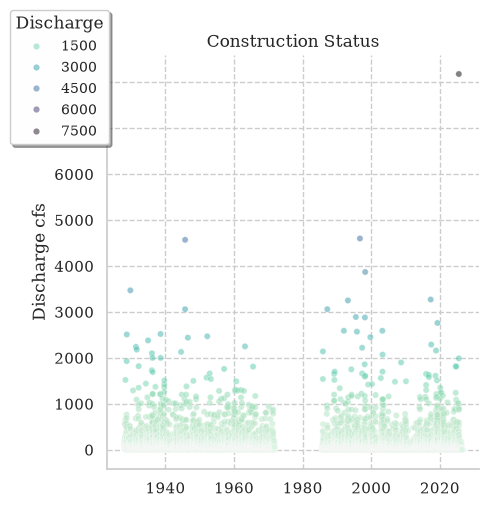

In [9]:
# Create a line plot of discharge over time
g = sns.relplot(
    data=USGS_flow,
    x='datetime',
    y='discharge_mean',
    hue= 'discharge_mean',
    palette='mako_r',
    alpha = .5,
    s=20
)

g.set(
    title='Construction Status',
    xlabel="",
    ylabel='Discharge cfs',
   
)

g = sns.move_legend(
    g,
    loc='right', #Switch to "upper left"
    title='Discharge',
    facecolor="#FFFEFE",
    shadow=True,
    bbox_to_anchor=(0.2,0.92),
    title_fontsize=12,
    fontsize=10,
    ncols=1,
    frameon=True
    
)


#### ✅ Question
**Would you say this is a useful plot? Why or why not? What might improve it?**
> **Answer**:  
>  I think it's a helpful way to se when the construction was and the clear gap in daily discharge, but I think there are better analysis to run such as trends in daily discharge across years, seasons, during climatic cycles (e.g. drought or el nino year), etc. 

---
#### 📊Task 2: Plot the number of records with valid minimum discharge values by year
* Determine which plot function to use: `relplot()`, `displot()`, or `catplot()`
* Determine which subplot function to use (e.g. "scatterplot" for relplot, "swarmplot" for catplot).
* Craft your plot to use the appropriate dataset and which variables to assign to which axes.
* Adjust the style of your plot to look tidy and professional:
    - Set the height and aspect of your plot to ensure it's clear and uses space accordingly.
    - Give your plot a title, and set axis labels appropriately. (Note: "Year' is an optional label when obvious.)

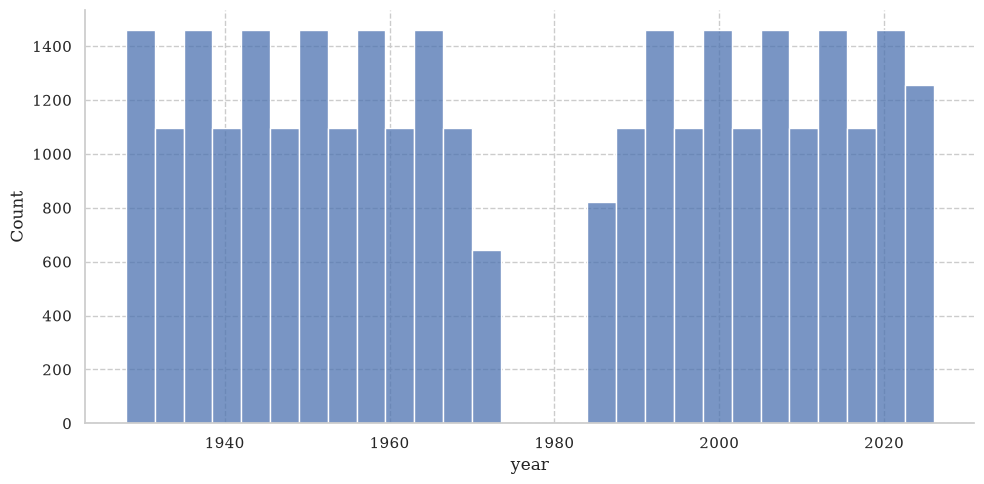

In [ ]:
# Plot the number of records by year

g = sns.displot(
    data=USGS_flow.loc[
        USGS_flow['discharge_mean'] > 0],
    x='year',
    kind='hist',
    aspect=2,)


##### ✅Question:
**What does this plot reveal about when the USGS recorded minimum and maximum discharge?**
> **Answer**
>It doesn't say anything. This is a count graph looking at days where the discharge mean was above 0 and a clear pattern alternating every year 

---
#### 📊Task 3: Plot the distribution of mean discharge by month
We want to examine monthly trends in discharge: is more water flowing through the sites some months than others? Is there a trend across months? To explore this, construct a plot that displays the typical (mean or median) discharge in a given month as well as some indication of the range of values. As before, make this plot tidy and professional. 


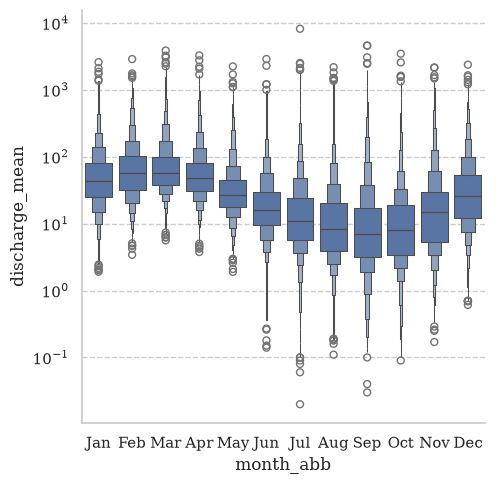

In [25]:
# Plot mean discharge by month
sns.catplot(
    data=USGS_flow.loc[
        USGS_flow['discharge_mean'] > 0
    ],
    x='month_abb',
    y='discharge_mean',
    kind='boxen',
    log_scale=True
)

---
#### 📊Task 4: Alter the above plot to compare trends before and after dam construction
* Copy and paste your above code into the code cell below
* Color the monthly mean discharge values by the dam construction category.
* Change your plot type to `point`.

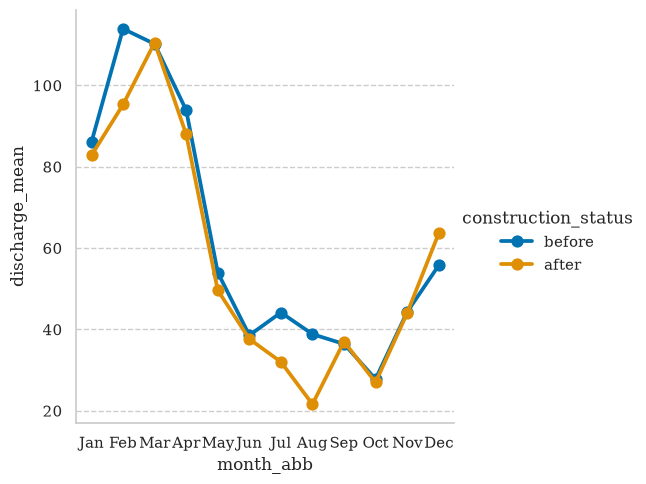

In [32]:
# Plot mean discharge by month, with separate plot features for records before and after dam construction

# Plot mean discharge by month
sns.catplot(
    data=USGS_flow.loc[USGS_flow['construction_status'].notna()],
    x='month_abb',
    y='discharge_mean',
    hue='construction_status',
    kind='point',
    palette='colorblind',
    errorbar=None,
)

##### ✅Question:
**Does this plot suggest any differences in monthly discharge patterns before/after the dam?**
> **Answer**
> Appears to be fairly similar except for July and August where there is a notable higher level of discharge_mean before construction occured. Would need to explore the broader context for why this may have occured to explain this difference. 

---
#### 📊Task 5: Split before/after dam construction as separate *facets*
* Show separate plots of monthly mean discharge
* Stack the plots vertically
* Assing the facetgrid object produced by your plotting to the variable `g`
* Append the code in the subsequent code cell to set titles and axes labels. (Note that facet plots produce a list of facetgrid objects that we can access individually).

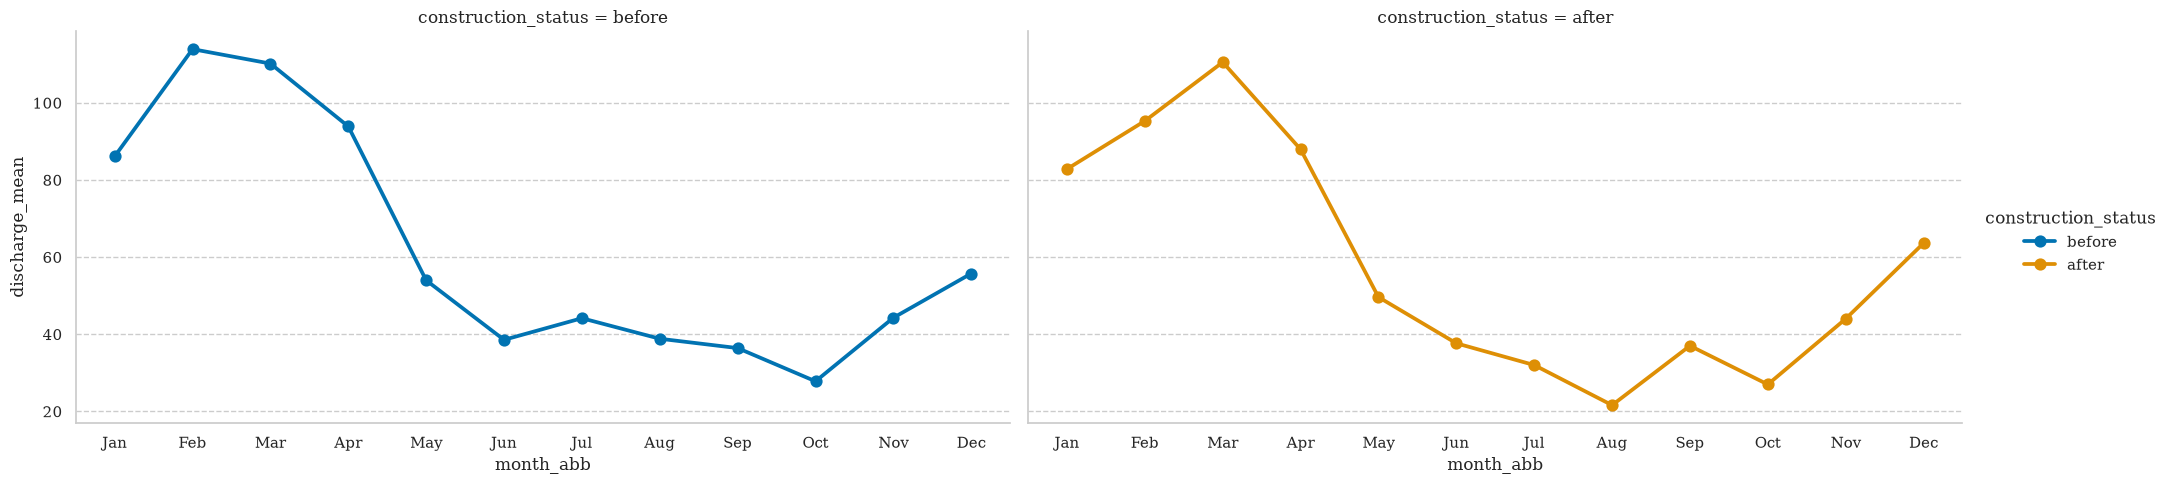

In [41]:
sns.catplot(
    data=USGS_flow.loc[USGS_flow['construction_status'].notna()],
    x='month_abb',
    y='discharge_mean',
    hue='construction_status',
    col='construction_status',
    kind='point',
    palette='colorblind',
    errorbar=None,
    height=5,
    aspect=2
)

AttributeError: 'numpy.ndarray' object has no attribute 'set'

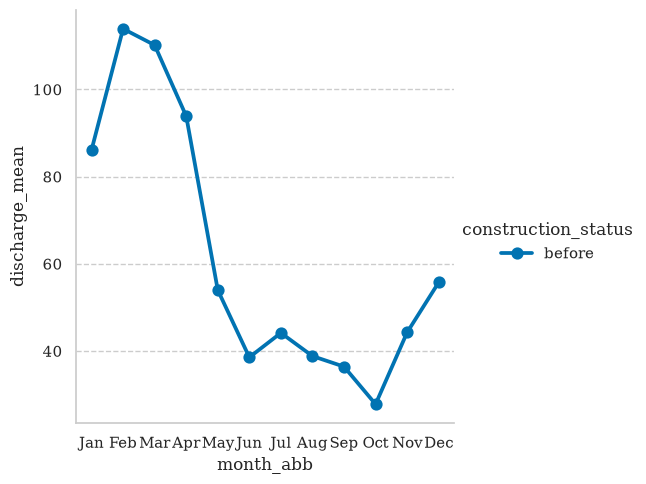

In [ ]:
# Split the plot of monthly mean discharges into facets of before and after construction
g = sns.catplot(
    data=USGS_flow.loc[
        (USGS_flow['construction_status'].notna())&
        (USGS_flow['construction_status']=='before')],
    x='month_abb',
    y='discharge_mean',
    hue='construction_status',
    kind='point',
    palette='colorblind',
    errorbar=None
)

g.axes[0].set(
    title = 'Monthly discharge: Before Dam Construction',
    xlabel= '',
    ylabel= 'Discharge (cfs)'
    )

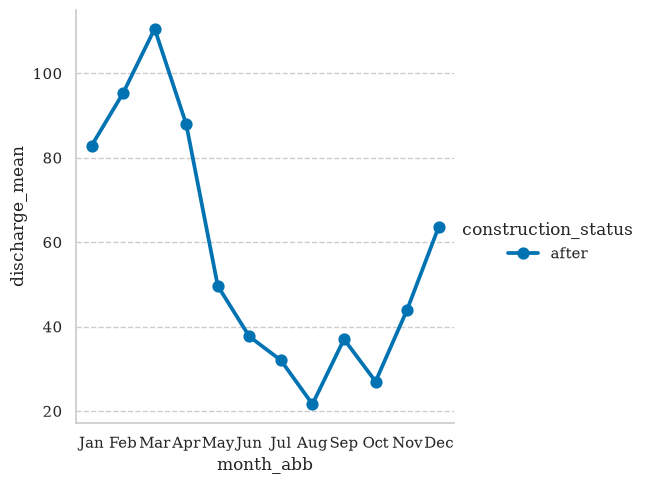

In [35]:
sns.catplot(
    data=USGS_flow.loc[
        (USGS_flow['construction_status'].notna())&
        (USGS_flow['construction_status']=='after')],
    x='month_abb',
    y='discharge_mean',
    hue='construction_status',
    kind='point',
    palette='colorblind',
    errorbar=None,
    color='orange'
)

In [49]:
print(type(g.axes))
print(g.axes.shape if hasattr(g.axes, 'shape') else 'no shape')
print(g.axes)


<class 'numpy.ndarray'>
(1, 2)
[[<Axes: title={'center': 'construction_status = before'}, xlabel='month_abb', ylabel='discharge_mean'>
  <Axes: title={'center': 'construction_status = after'}, xlabel='month_abb'>]]


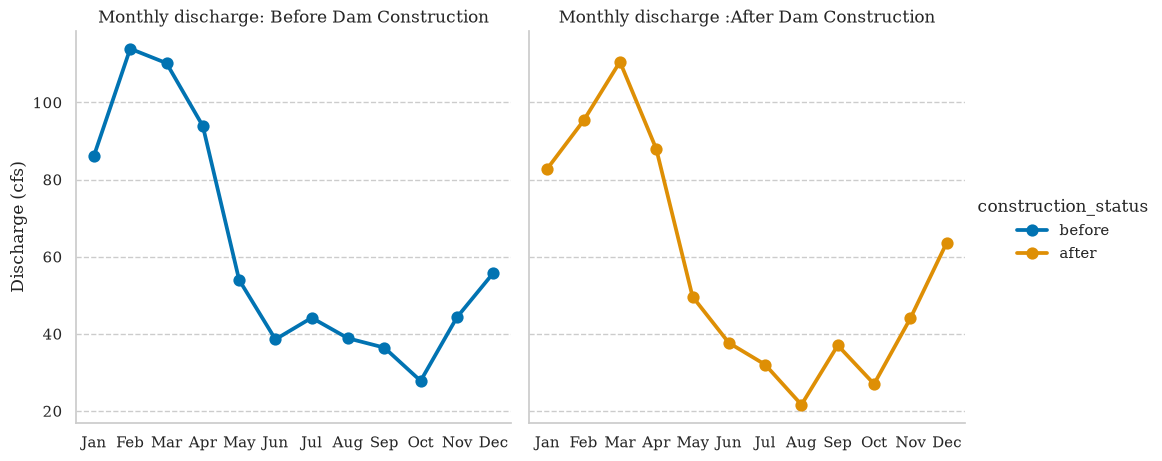

In [ ]:
# Merge this code cell with your code cell above 
g = sns.catplot(
    data=USGS_flow.loc[USGS_flow['construction_status'].notna()],
    x='month_abb',
    y='discharge_mean',
    hue='construction_status',
    col='construction_status',
    kind='point',
    palette='colorblind',
    errorbar=None,
)

g.axes[0,0].set(
    title = 'Monthly discharge: Before Dam Construction',
    xlabel= '',
    ylabel= 'Discharge (cfs)'
    )

g.axes[0,1].set(
    title = 'Discharge After Dam Construction',
    xlabel= '',
    ylabel= 'Discharge (cfs)'
    )

# Show the plot
g 

##### ✅Question:
**Which of the last two plots shows the data more effectively?**
> **Answer**
>I like the last one showing the comparison between the two 

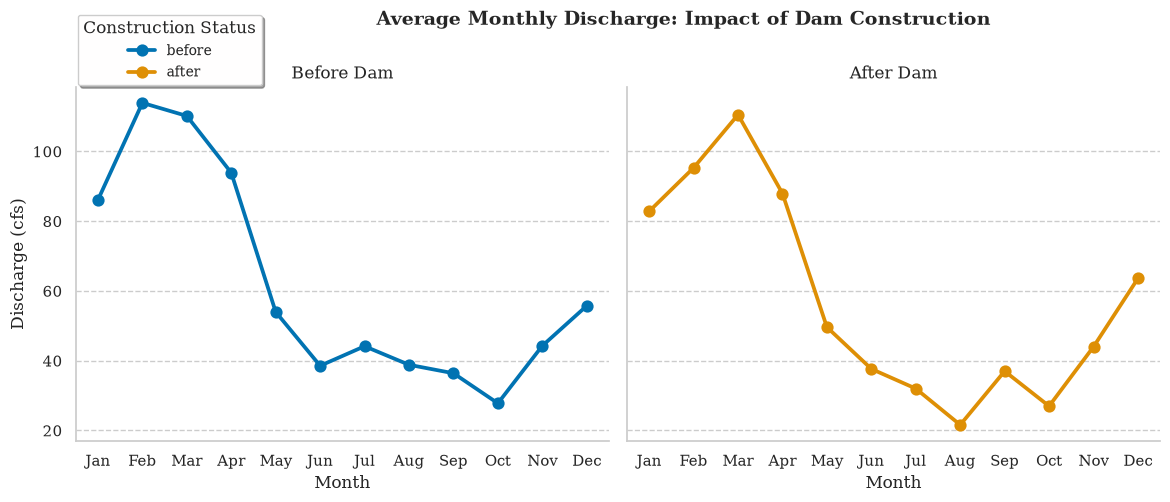

In [ ]:
#note. Was playing with AI to work on formatting here to get to one, clean centralized graph. 

g = sns.catplot(
    data=USGS_flow.loc[USGS_flow['construction_status'].notna()],
    x='month_abb',
    y='discharge_mean',
    hue='construction_status',
    col='construction_status',
    kind='point',
    palette='colorblind',
    errorbar=None,
    height=5,
    aspect=1.2
)

# Main title above both subplots
g.fig.suptitle('Average Monthly Discharge: Impact of Dam Construction', 
               fontsize=14, fontweight='bold', y=1.00)

# Individual subplot titles
g.axes[0, 0].set(
    title='Before Dam',
    xlabel='Month',
    ylabel='Discharge (cfs)'
)

g.axes[0, 1].set(
    title='After Dam',
    xlabel='Month',
    ylabel=''  # Remove to avoid redundancy
)

# Add more breathing room
g.tight_layout()


g = sns.move_legend(
    g,
    loc='right', #Switch to "upper left"
    title='Construction Status',
    facecolor="#FFFEFE",
    shadow=True,
    bbox_to_anchor=(0.2,0.92),
    title_fontsize=12,
    fontsize=10,
    ncols=1,
    frameon=True)
